# 2025年度 IoPサマースクール #8 演習2

気象衛星「ひまわり」の観測データ（2025年8月分）を使用し、  
**日射量を予測する機械学習モデル**を構築します。


In [1]:
# 使用するライブラリを読み込み
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras import Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    Concatenate, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LinearRegression



In [2]:
# ひまわりデータ2025年8月分のダウンロード
!git clone https://github.com/ikunao/250909_SS8
!unzip ./250909_SS8/himawari.zip -d /content/


Cloning into '250909_SS8'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 34 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 17.31 MiB | 9.19 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Archive:  ./250909_SS8/himawari.zip
   creating: /content/b03_japan/
  inflating: /content/b03_japan/202508010000.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010100.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010200.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010300.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010400.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010500.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010600.ext.01.rad.fld.4km.bin.bz2.jpg  
  inflating: /content/b03_japan/202508010700.ext.

In [203]:
# ひまわりデータの読み込み
path_b03 = '/content/b03_japan/*.jpg'
path_b06 = '/content/b06_japan/*.jpg'
path_b13 = '/content/b13_japan/*.jpg'

x1 = []
x2 = []
x3 = []

for i in range(len(sorted(glob.glob(path_b06)))):
    image1 = Image.open(sorted(glob.glob(path_b03))[i]).convert('L')
    image2 = Image.open(sorted(glob.glob(path_b06))[i]).convert('L')
    image3 = Image.open(sorted(glob.glob(path_b13))[i]).convert('L')

    x1.append(np.array([image1,image2,image3]))

x1 = (x1 - np.mean(x1)) / (np.max(x1) - np.min(x1))

x = x1
x = x[0:720,:,80:140,180:240]     #8/1～8/15分のみ
x.shape

(720, 3, 60, 60)

(720, 3, 60, 60)


TypeError: Invalid shape (3, 60, 60) for image data

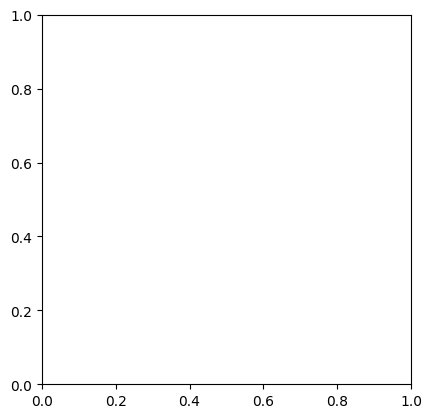

In [204]:
# ひまわりデータの可視化

print(np.array(x).shape)
plt.imshow(x[0])  #5枚目の画像、Y方向50:150, X方向全部、最初のバンドを表示。

In [153]:
# 高知気象台環境情報データをデータフレーム格納

df = pd.read_csv(
    '/content/kisho_kochi.csv',
    encoding='shift_jis',
    parse_dates=['年月日時'],
    index_col='年月日時'
)
y = np.array(df["日射量"], dtype=np.float32)               #目的変数
w1 = np.array(df["晴天時日射量"], dtype=np.float32)        #説明変数
w1 = (w1 - np.mean(w1)) / (np.max(w1) - np.min(w1) + 1e-6)
w = w1

y = y[0:720]
w = w[0:720]

In [154]:
# 環境情報の確認
print(df[:20])


                      日射量    気温  相対湿度  降水量    現地気圧    晴天時日射量
年月日時                                                        
2025-08-01 00:00:00  2.01  31.6    63  0.0  1002.4  2.390500
2025-08-01 01:00:00  2.53  32.3    63  0.0  1002.1  2.925860
2025-08-01 02:00:00  3.05  33.3    60  0.0  1001.5  3.282055
2025-08-01 03:00:00  3.32  34.0    53  0.0  1001.1  3.433430
2025-08-01 04:00:00  3.35  34.4    51  0.0  1000.7  3.369275
2025-08-01 05:00:00  3.17  34.0    46  0.0  1000.4  3.094000
2025-08-01 06:00:00  2.77  33.4    48  0.0  1000.2  2.627240
2025-08-01 07:00:00  1.51  32.6    52  0.0  1000.3  2.002945
2025-08-01 08:00:00  1.01  31.9    58  0.0  1000.4  1.269905
2025-08-01 09:00:00  0.30  31.5    61  0.0  1000.8  0.504105
2025-08-01 10:00:00  0.13  30.8    65  0.0  1000.8  0.001960
2025-08-01 11:00:00  0.00  30.1    69  0.0  1001.1  0.000000
2025-08-01 12:00:00  0.00  29.6    71  0.0  1001.4  0.000000
2025-08-01 13:00:00  0.00  29.0    74  0.0  1001.3  0.000000
2025-08-01 14:00:00  0.0

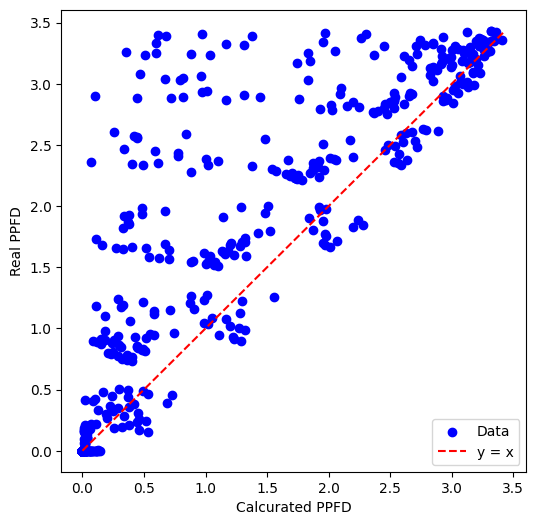

In [155]:
# 晴天時日射量と実際の日射量の相関

plt.figure(figsize=(6, 6))
plt.scatter(df["日射量"], df["晴天時日射量"], color='blue', label='Data')

min_val = min(df["日射量"].min(), df["晴天時日射量"].min())
max_val = max(df["日射量"].max(), df["晴天時日射量"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel('Calcurated PPFD')
plt.ylabel('Real PPFD')
plt.legend()
plt.show()


In [210]:
# 学習データと検証データに分離（前66% → train、後33% → val）
split_idx = int(len(x) * 0.66)
x_train, x_val = x[:split_idx], x[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]
w_train, w_val = w[:split_idx], w[split_idx:]

In [211]:
from tensorflow.keras.layers import Reshape




# 画像の畳み込み
image_input = Input(shape=(3,60,60, 1))
v = Reshape((60, 60, 3))(image_input)

v = Conv2D(8, (3, 3), activation='relu', padding='same')(v)
v = MaxPooling2D((2, 2))(v)
v = Conv2D(16, (3, 3), activation='relu', padding='same')(v)
v = MaxPooling2D((2, 2))(v)
v = Conv2D(32, (3, 3), activation='relu', padding='same')(v)
v = GlobalAveragePooling2D()(v)
v = Dense(32, activation='relu')(v)

# 数値データのNN
meta_input = Input(shape=(1,))    #インプットデータのshapeに合わせる
m = Dense(8, activation='relu')(meta_input)
m = Dense(8, activation='relu')(m)

# 画像と数値を結合
combined = Concatenate()([v, m])
output = Dense(1, activation='linear')(combined)

# モデル構築
model = Model(inputs=[image_input, meta_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')


In [212]:
# モデル学習
history = model.fit(
    [x_train, w_train], y_train,
    validation_data=([x_val, w_val], y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - loss: 1.4543 - val_loss: 1.2510
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 1.1550 - val_loss: 1.1127
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 1.0433 - val_loss: 0.9681
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.9331 - val_loss: 0.8126
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.8325 - val_loss: 0.6758
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.6979 - val_loss: 0.5137
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.5807 - val_loss: 0.4043
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.4556 - val_loss: 0.3146
Epoch 9/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.3616 - val_loss: 0.2399
Epoch 10/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.3215 - val_loss: 0.2419
Epoch 11/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.2968 - val_loss: 0.2023
Epoch 12/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0

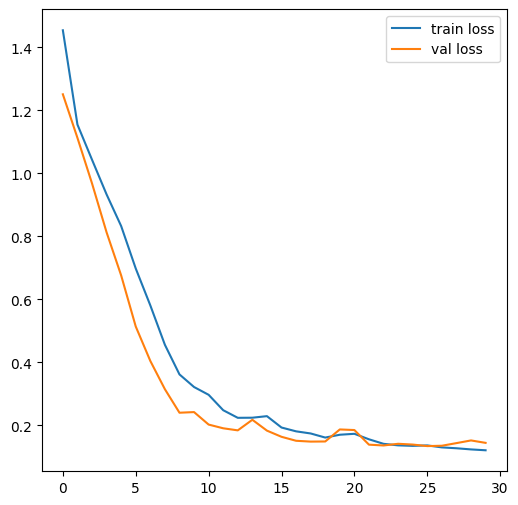

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


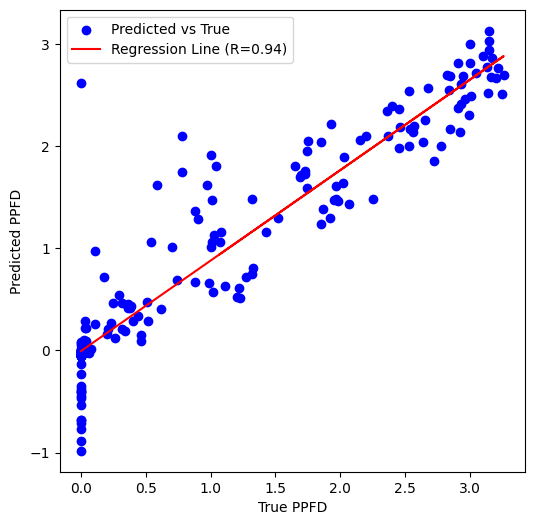

In [213]:
# 学習曲線
plt.figure(figsize=(6, 6))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

# 予測値
y_pred = model.predict([x_val,w_val]).flatten()

# 相関係数
r_value = np.corrcoef(y_val, y_pred)[0, 1]

# 回帰直線
reg_model = LinearRegression()
reg_model.fit(y_val.reshape(-1, 1), y_pred)
reg_line = reg_model.predict(y_val.reshape(-1, 1))

# 描画
plt.figure(figsize=(6, 6))
plt.scatter(x=y_val, y=y_pred, color='blue', label='Predicted vs True')
plt.plot(y_val, reg_line, color='red', label=f'Regression Line (R={r_value:.2f})')
plt.xlabel('True PPFD')
plt.ylabel('Predicted PPFD')
plt.legend()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


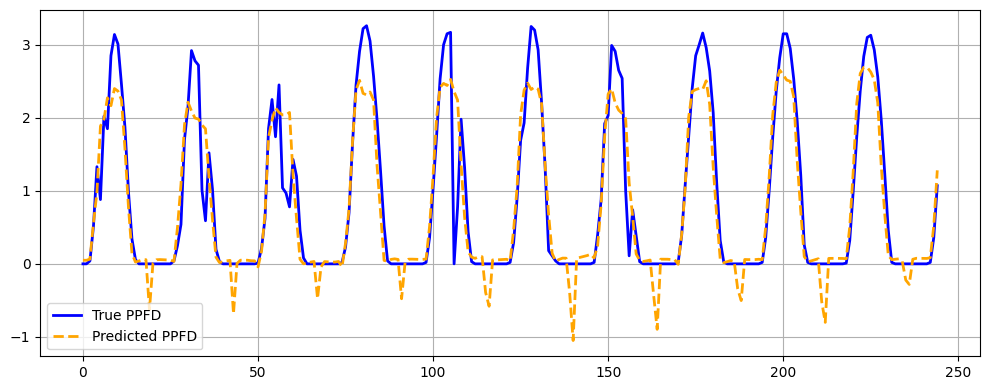

In [197]:
# 時系列結果の表示（学習に使用しなかった後半）
y_pred = model.predict([x_val,w_val]).flatten()
time_index = np.arange(len(y_val))

# グラフの描画
plt.figure(figsize=(10, 4))
plt.plot(time_index, y_val, label='True PPFD', color='blue', linewidth=2)
plt.plot(time_index, y_pred, label='Predicted PPFD', color='orange', linestyle='--', linewidth=2)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


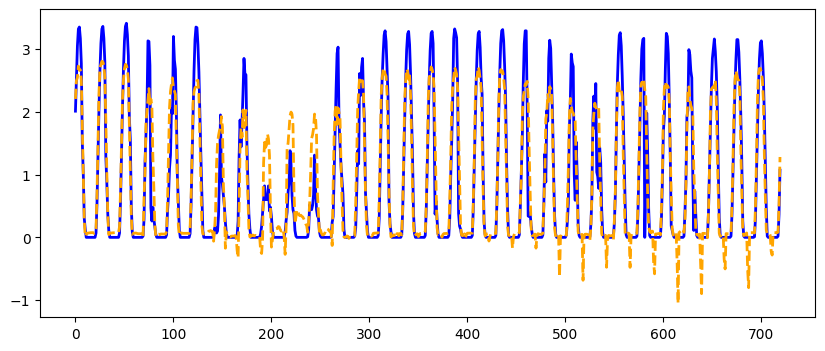

In [198]:
# 時系列結果の表示（全期間）
y_pred = model.predict([x,w]).flatten()
time_index = np.arange(len(y))

plt.figure(figsize=(10, 4))
plt.plot(time_index, y, label='True PPFD', color='blue', linewidth=2)
plt.plot(time_index, y_pred, label='Predicted PPFD', color='orange', linestyle='--', linewidth=2)


In [14]:
x.shape


(360, 200, 400)

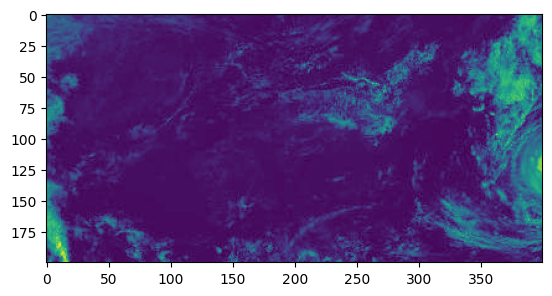

In [35]:
plt.imshow(x[0])

最新観測時刻(UTC): 2026-08-25 06:20:00


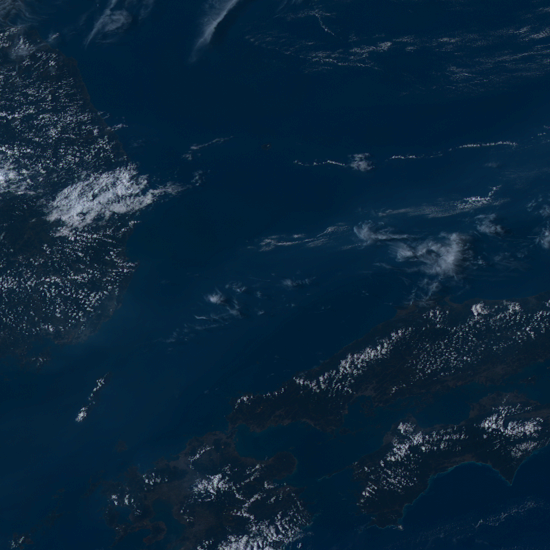

In [71]:
import requests, io
from PIL import Image
import numpy as np

BASE = "https://himawari8-dl.nict.go.jp/himawari8/img/D531106"

# 最新観測時刻を取得
latest = requests.get(f"{BASE}/latest.json").json()["date"]  # "YYYY-MM-DD HH:MM:SS" (UTC)
print("最新観測時刻(UTC):", latest)

d, t = latest.split(" ")
Y, M, D = d.split("-")
hhmm = t.replace(":", "")[:4]

# 分割数（1,4,8,16,20）。大きいほど高解像度
LEVEL = 20
SIZE  = 550

# 高知付近が含まれるタイル座標を探す（要調整）
tiles = [(8, 3)]

for x, y in tiles:
    url = f"{BASE}/{LEVEL}d/{SIZE}/{Y}/{M}/{D}/{hhmm}00_{x}_{y}.png"
    r = requests.get(url)
    if r.status_code == 200:
        img = Image.open(io.BytesIO(r.content))
        display(img)

In [73]:
!wget https://data.earth.jaxa.jp/api/python/v0.1.4/en/_downloads/c1dbe3f6901b028a5ee3a4f25519a590/jaxa-earth-0.1.4.zip
!pip install jaxa-earth-0.1.4.zip

--2026-08-25 06:52:59--  https://data.earth.jaxa.jp/api/python/v0.1.4/en/_downloads/c1dbe3f6901b028a5ee3a4f25519a590/jaxa-earth-0.1.4.zip
Resolving data.earth.jaxa.jp (data.earth.jaxa.jp)... 159.60.133.108
Connecting to data.earth.jaxa.jp (data.earth.jaxa.jp)|159.60.133.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68481 (67K) [application/zip]
Saving to: ‘jaxa-earth-0.1.4.zip’

jaxa-earth-0.1.4.zi 100%[===================>]  66.88K   329KB/s    in 0.2s    

2026-08-25 06:53:00 (329 KB/s) - ‘jaxa-earth-0.1.4.zip’ saved [68481/68481]

Processing ./jaxa-earth-0.1.4.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jaxa-earth: filename=jaxa_earth-0.1.4-py3-none-any.whl size=47459 sha256=63037edc30d110414ae14c7f16011f9b02f43596660945da2a05a6a22850de18
  Stored in directory: /root/.cache/pip/wheels/cf/2b/68/a50483b8e071196552172e402e00aff72bb0f90a06185

In [82]:
from jaxa.earth import je
import datetime
import numpy as np
import matplotlib.pyplot as plt
def je_get(collection, band, ppu, bbox, sdate, edate):
    """Get a data array from the JAXA Earth
    ppu : pixels per unit
    bbox : bounding box [lon_min, lat_min, lon_max, lat_max]
    sdate : start date ([year, month, day] or datetime.datetime instance)
    edate : end date ([year, month, day] or datetime.datetime instance)
    """
    if isinstance(sdate, datetime.datetime):
        sdt = sdate
    else:
        sdt = datetime.datetime(year=sdate[0], month=sdate[1], day=sdate[2])
    if isinstance(edate, datetime.datetime):
        edt = edate
    else:
        edt = datetime.datetime(year=edate[0], month=edate[1], day=edate[2])

    data = je.ImageCollection(collection=collection, ssl_verify=False)\
                    .filter_date(dlim=[sdt.isoformat(), edt.isoformat()])\
                    .filter_resolution(ppu=ppu)\
                    .filter_bounds(bbox=bbox)\
                    .select(band=band)\
                    .get_images()
    img = je.ImageProcess(data)
    im = img.raster.img[:, :, :, 0]
    return im  # (Days, Height, Width) numpy.ndarray

In [91]:
ppu = 2.5  # points per unit (should be 2.5 for this hands-on)
bbox = [90, 0, 170, 60]  # bounding box [lon_min, lat_min, lon_max, lat_max]


# Precipitation Rate (Daily)
# https://data.earth.jaxa.jp/en/datasets/#/id/JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_daily
rain = je_get(
    collection="https://s3.ap-northeast-1.wasabisys.com/je-pds/cog/v1/JAXA.EORC_ALOS_HRLULC.v25.04_japan/collection.json",
    band="HRLULC",
    ppu=ppu, bbox=bbox,
    sdate=[2024, 4, 1],  # start date (year, month, day)
    edate=[2024, 4, 3]  # end date (year, month, day) (inclusive)
)
rain.shape


 - Collection : 

Exception: Error! Requested collection name was not found !
requested : https://s3.ap-northeast-1.wasabisys.com/je-pds/cog/v1/JAXA.EORC_ALOS_HRLULC.v25.04_japan/collection.json

In [85]:
# https://data.earth.jaxa.jp/en/datasets/#/id/JAXA.JASMES_Aqua.MODIS_swr.v811_global_daily
radiation = je_get(
    collection="JAXA.JASMES_Aqua.MODIS_swr.v811_global_daily",
    band="swr",
    ppu=ppu, bbox=bbox,
    sdate=[2024, 4, 1],  # start date (year, month, day)
    edate=[2024, 4, 3]  # end date (year, month, day) (inclusive)
)
radiation.shape

 - Collection : JAXA.JASMES_Aqua.MODIS_swr.v811_global_daily
 - Date : 2024-04/01/, 2024-04/02/, 2024-04/03/, 
 - Resolution : 2.5 pixels per 1 degree 
 - Bounds : [90, 0, 170, 60]
 - Band : swr
 - Loading images No.0 : 2024-04/01/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - Loading images No.1 : 2024-04/02/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - Loading images No.2 : 2024-04/03/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - ROI mask : masked


(3, 150, 200)

 - Collection : JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_daily
 - Date : 2026-07/01/, 2026-07/02/, 2026-07/03/, 
 - Resolution : 5.0 pixels per 1 degree 
 - Bounds : [130.0, 30.0, 145.0, 45.0]
 - Band : PRECIP
 - Loading images No.0 : 2026-07/01/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - Loading images No.1 : 2026-07/02/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - Loading images No.2 : 2026-07/03/
   ------10------20------30------40------50------60------70------80------90-----100
   ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 - ROI mask : masked
 - Show images : 

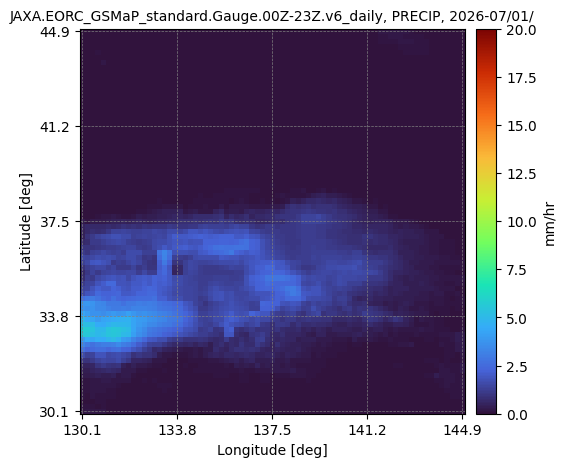

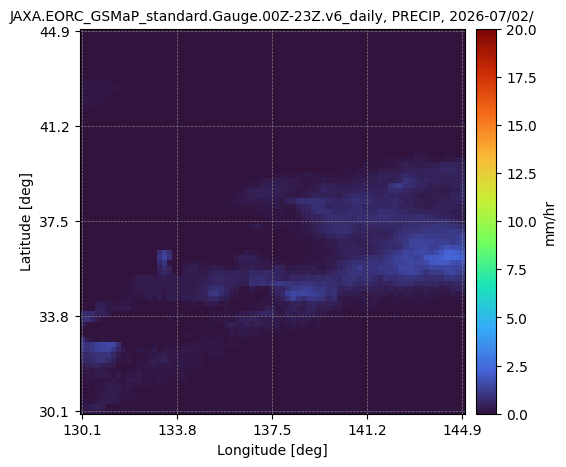

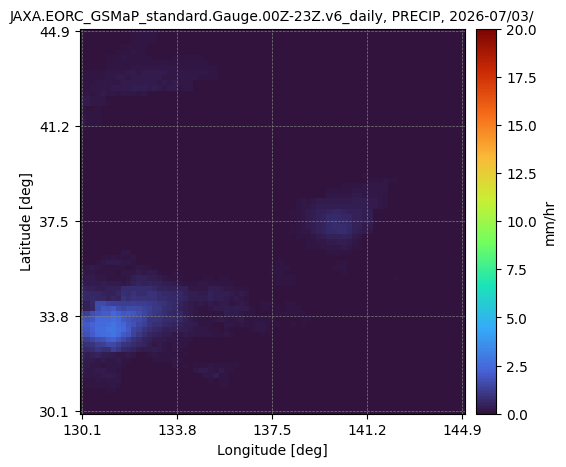

showed


In [97]:
ic = je.ImageCollection(
    collection="JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_daily"
)
ic.filter_date(dlim=["2026-07-01T00:00:00", "2026-07-03T00:00:00"])
ic.filter_resolution(ppu=4)
ic.filter_bounds(bbox=[130.0, 30.0, 145.0, 45.0])
ic.select(band="PRECIP")
ic.get_images()

# 3. 画像処理・可視化
ip = je.ImageProcess(data=ic)
ip.show_images(cmap="turbo", clim=[0, 20])

In [93]:
collectionscollections


['JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_half-monthly-normal',
 'JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_monthly-normal',
 'JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_daily',
 'JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_half-monthly',
 'JAXA.EORC_GSMaP_standard.Gauge.00Z-23Z.v6_monthly',
 'JAXA.EORC_GSMaP_NRT.Gauge.Ext.00Z-23Z.v6_daily',
 'JAXA.EORC_GSMaP_standard.Gauge.v6_hourly',
 'JAXA.EORC_GSMaP_SPI.climate.gnrt6_monthly']

In [192]:
x.shape


(720, 3, 100, 100)